In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "data" / "raw").exists(), (
    f"Could not find data/raw from {Path.cwd()}. "
    "Open the notebook from the project notebooks folder."
)

sys.path.insert(0, str(PROJECT_ROOT))

from src.phase1 import run_phase1

print("Project root:", PROJECT_ROOT)

Project root: D:\downloads\project\Diabetic-Retinopathy-Screening-Project


In [2]:
expected_paths = [
    "data/raw/aptos/train_images",
    "data/raw/aptos/test_images",
    "data/raw/aptos/train.csv",
    "data/raw/aptos/test.csv",
    "data/raw/eyepacs/data",
    "data/raw/eyepacs/trainLabels.csv",
    "data/raw/idrid/A. Segmentation",
    "data/raw/idrid/B. Disease Grading",
    "data/raw/idrid/C. Localization",
    "data/raw/messidor2/preprocess",
    "data/raw/messidor2/messidor_data.csv",
]

for relative_path in expected_paths:
    path = PROJECT_ROOT / relative_path
    print(f"{'OK' if path.exists() else 'MISSING'}  {relative_path}")

OK  data/raw/aptos/train_images
OK  data/raw/aptos/test_images
OK  data/raw/aptos/train.csv
OK  data/raw/aptos/test.csv
OK  data/raw/eyepacs/data
OK  data/raw/eyepacs/trainLabels.csv
OK  data/raw/idrid/A. Segmentation
OK  data/raw/idrid/B. Disease Grading
OK  data/raw/idrid/C. Localization
OK  data/raw/messidor2/preprocess
OK  data/raw/messidor2/messidor_data.csv


In [3]:
#run inspection, validation, quality metrics, duplicate checks, and master metadata
master = run_phase1(
    root=PROJECT_ROOT,
    workers=1,
    run_preprocessing=False,  # Inspect first; create derived images only after review
)

master.head()


train.csv
Columns found: ['id_code', 'diagnosis']
Using image column: id_code; label column: diagnosis

trainLabels.csv
Columns found: ['image', 'level']
Using image column: image; label column: level

a. IDRiD_Disease Grading_Training Labels.csv
Columns found: ['Image name', 'Retinopathy grade', 'Risk of macular edema ', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']
Using image column: Image name; label column: Retinopathy grade

messidor_data.csv
Columns found: ['id_code', 'diagnosis', 'adjudicated_dme', 'adjudicated_gradable']
Using image column: id_code; label column: diagnosis


KeyboardInterrupt: 

In [4]:
print((PROJECT_ROOT / "data/interim/standardized_metadata.csv").exists())
print((PROJECT_ROOT / "reports/tables/image_validation.csv").exists())

True
True


In [7]:
metadata = pd.read_csv(
    PROJECT_ROOT / "data/interim/standardized_metadata.csv"
)

dataset_summary = (
    metadata.groupby(["dataset", "source_split"], dropna=False)
    .agg(
        images=("image_key", "count"),
        labeled_images=("has_label", "sum"),
    )
    .reset_index()
)

dataset_summary.to_csv(
    PROJECT_ROOT / "reports/tables/dataset_summary.csv",
    index=False,
)

dataset_summary

,dataset,source_split,images,labeled_images
0,aptos,test,1928,0
1,aptos,train,3662,3662
2,eyepacs,train,35126,35126
3,idrid,test,27,0
4,idrid,train,54,0
5,messidor2,unknown,1744,1744


In [8]:
pd.read_csv(PROJECT_ROOT / "reports/tables/dataset_summary.csv")

,dataset,source_split,images,labeled_images
0,aptos,test,1928,0
1,aptos,train,3662,3662
2,eyepacs,train,35126,35126
3,idrid,test,27,0
4,idrid,train,54,0
5,messidor2,unknown,1744,1744


In [10]:
metadata = pd.read_csv(
    PROJECT_ROOT / "data/interim/standardized_metadata.csv"
)

validation = pd.read_csv(
    PROJECT_ROOT / "reports/tables/image_validation.csv"
)

master = metadata.merge(
    validation,
    on="image_key",
    how="left",
)

master.head()

,dataset,image_key,image_id,source_split,official_split,image_path,extension,label_dr,has_label,label_source,is_readable,width,height,pil_format,validation_error
0,aptos,aptos__8a58801bb4e89fda,000c1434d8d7,train,NaN,data/raw/aptos/train_images/000c1434d8d7.png,.png,2.0,True,aptos/train.csv,True,3216,2136,PNG,NaN
1,aptos,aptos__c8827d05711175da,001639a390f0,train,NaN,data/raw/aptos/train_images/001639a390f0.png,.png,4.0,True,aptos/train.csv,True,3216,2136,PNG,NaN
2,aptos,aptos__2b8228ecc008b575,0024cdab0c1e,train,NaN,data/raw/aptos/train_images/0024cdab0c1e.png,.png,1.0,True,aptos/train.csv,True,2416,1736,PNG,NaN
3,aptos,aptos__f9409e06017fe46c,002c21358ce6,train,NaN,data/raw/aptos/train_images/002c21358ce6.png,.png,0.0,True,aptos/train.csv,True,1050,1050,PNG,NaN
4,aptos,aptos__11b2efaae2c39263,005b95c28852,train,NaN,data/raw/aptos/train_images/005b95c28852.png,.png,0.0,True,aptos/train.csv,True,2048,1536,PNG,NaN


In [11]:
problems = master.loc[
    ~master["is_readable"].fillna(False),
    ["dataset", "image_id", "image_path", "validation_error"]
]

print("Unreadable images:", len(problems))
problems.head(20)


Unreadable images: 0


,dataset,image_id,image_path,validation_error


In [12]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the completed earlier stages
metadata = pd.read_csv(
    PROJECT_ROOT / "data/interim/standardized_metadata.csv"
)

validation = pd.read_csv(
    PROJECT_ROOT / "reports/tables/image_validation.csv"
)

# Fuse the standardized metadata with validation results
master = metadata.merge(
    validation,
    on="image_key",
    how="left",
)

# Record honestly which expensive stages were intentionally deferred
master["quality_status"] = "not_run_full_dataset"
master["duplicate_check_status"] = "not_run_full_dataset"
master["preprocess_status"] = "not_run"

# Preserve the official IDRiD split; this verifies it was not changed
idrid_splits = set(
    master.loc[master["dataset"] == "idrid", "official_split"]
    .dropna()
    .unique()
)
assert idrid_splits.issubset({"train", "test"}), (
    f"Unexpected IDRiD split values: {idrid_splits}"
)

# Save the Phase 1 master metadata
tables_dir = PROJECT_ROOT / "reports" / "tables"
figures_dir = PROJECT_ROOT / "reports" / "figures"
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

master.to_csv(
    tables_dir / "master_metadata_phase1.csv",
    index=False,
)

# Create a useful dataset summary
dataset_summary = (
    master.groupby(["dataset", "source_split"], dropna=False)
    .agg(
        images=("image_key", "count"),
        labeled_images=("has_label", "sum"),
        unreadable_images=(
            "is_readable",
            lambda values: int((~values.fillna(False)).sum()),
        ),
    )
    .reset_index()
)

dataset_summary.to_csv(
    tables_dir / "dataset_summary.csv",
    index=False,
)

# Record the deliberate Phase 1 decisions
pd.DataFrame(
    [
        {
            "stage": "Image quality features",
            "status": "Deferred",
            "reason": "Full-dataset quality scan was too slow on the local laptop.",
        },
        {
            "stage": "Duplicate detection",
            "status": "Deferred",
            "reason": "Full near-duplicate comparison was too slow on the local laptop.",
        },
        {
            "stage": "Image preprocessing",
            "status": "Deferred",
            "reason": "Derived images will be generated later after quality review.",
        },
    ]
).to_csv(tables_dir / "phase1_deferred_steps.csv", index=False)

dataset_summary

,dataset,source_split,images,labeled_images,unreadable_images
0,aptos,test,1928,0,0
1,aptos,train,3662,3662,0
2,eyepacs,train,35126,35126,0
3,idrid,test,27,0,0
4,idrid,train,54,0,0
5,messidor2,unknown,1744,1744,0


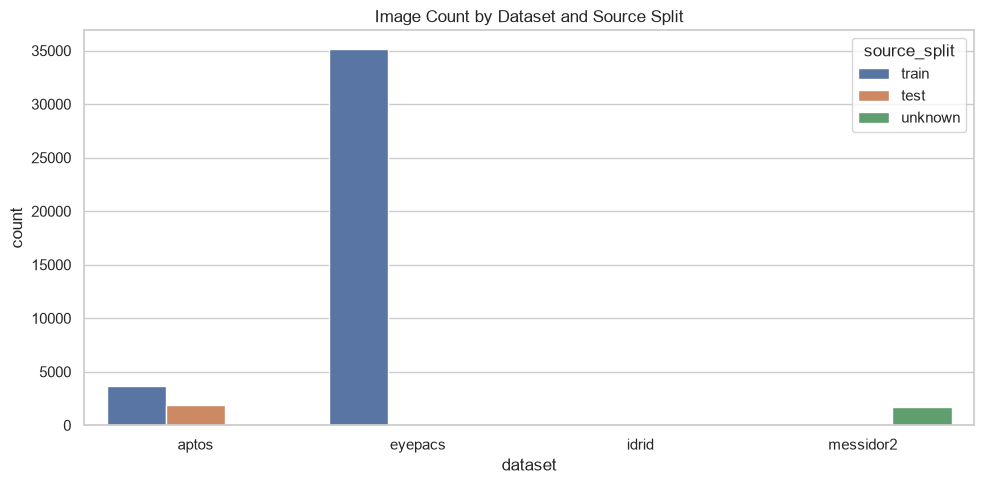

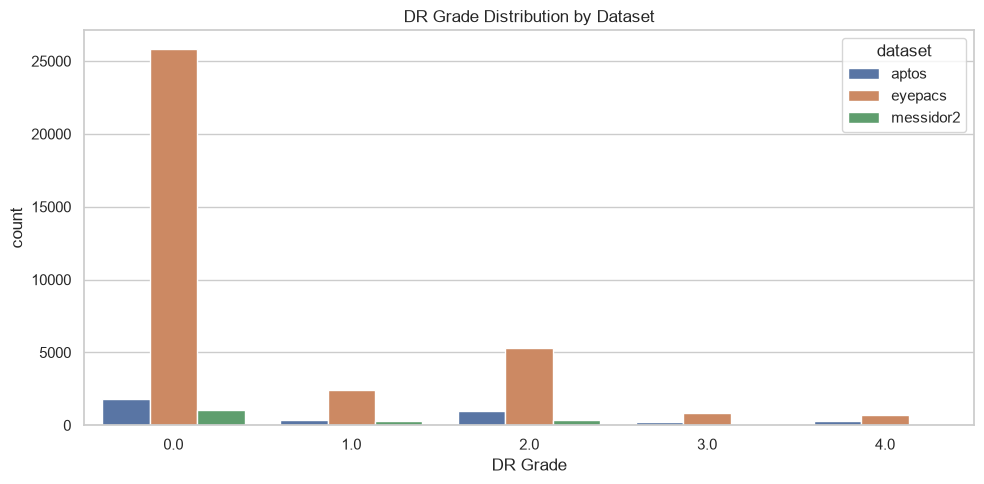

In [13]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.countplot(data=master, x="dataset", hue="source_split")
plt.title("Image Count by Dataset and Source Split")
plt.tight_layout()
plt.savefig(figures_dir / "dataset_split_counts.png", dpi=160)
plt.show()

labeled = master.dropna(subset=["label_dr"]).copy()

plt.figure(figsize=(10, 5))
sns.countplot(data=labeled, x="label_dr", hue="dataset")
plt.title("DR Grade Distribution by Dataset")
plt.xlabel("DR Grade")
plt.tight_layout()
plt.savefig(figures_dir / "dr_grade_distribution.png", dpi=160)
plt.show()

In [14]:
problems = master.loc[
    ~master["is_readable"].fillna(False),
    ["dataset", "image_id", "image_path", "validation_error"],
]

print("Unreadable images:", len(problems))
problems.head(20)

Unreadable images: 0


,dataset,image_id,image_path,validation_error


In [15]:
import importlib
import src.phase1
importlib.reload(src.phase1)

from src.phase1 import build_standard_metadata

# Rebuild metadata with corrected IDRiD label matching.
metadata = build_standard_metadata(PROJECT_ROOT)

# Reuse the image validation that already finished.
validation = pd.read_csv(
    PROJECT_ROOT / "reports/tables/image_validation.csv"
)

master = metadata.merge(
    validation,
    on="image_key",
    how="left",
)

master.to_csv(
    PROJECT_ROOT / "reports/tables/master_metadata_phase1.csv",
    index=False,
)

dataset_summary = (
    master.groupby(["dataset", "source_split"], dropna=False)
    .agg(
        images=("image_key", "count"),
        labeled_images=("has_label", "sum"),
        unreadable_images=(
            "is_readable",
            lambda values: int((~values.fillna(False)).sum()),
        ),
    )
    .reset_index()
)

dataset_summary.to_csv(
    PROJECT_ROOT / "reports/tables/dataset_summary.csv",
    index=False,
)

dataset_summary


train.csv
Columns found: ['id_code', 'diagnosis']
Using image column: id_code; label column: diagnosis

trainLabels.csv
Columns found: ['image', 'level']
Using image column: image; label column: level

a. IDRiD_Disease Grading_Training Labels.csv
Columns found: ['Image name', 'Retinopathy grade', 'Risk of macular edema ', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']
Using image column: Image name; label column: Retinopathy grade

messidor_data.csv
Columns found: ['id_code', 'diagnosis', 'adjudicated_dme', 'adjudicated_gradable']
Using image column: id_code; label column: diagnosis


,dataset,source_split,images,labeled_images,unreadable_images
0,aptos,test,1928,0,0
1,aptos,train,3662,3662,0
2,eyepacs,train,35126,35126,0
3,idrid,test,27,27,0
4,idrid,train,54,54,0
5,messidor2,unknown,1744,1744,0


In [16]:
master.loc[
    master["dataset"] == "idrid",
    ["source_split", "has_label"]
].groupby("source_split").sum()

,has_label
source_split,
test,27
train,54
